# TASK 4 — Fine-Tuning BERT on IMDB Dataset
**Pipeline:** Raw Data → Preprocessing → Tokenization → Model Training → Evaluation → Comparison

In [1]:
!pip install transformers datasets scikit-learn seaborn torch --quiet


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import re
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification

import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


## 1. Load Dataset

In [3]:
raw_dataset = load_dataset('imdb')

train_df = pd.DataFrame(raw_dataset['train'])
test_df  = pd.DataFrame(raw_dataset['test'])

# Using a subset for faster training
train_df = train_df.sample(n=2400, random_state=42, ignore_index=True)
test_df  = test_df.sample(n=600, random_state=42, ignore_index=True)

print(f'Train: {len(train_df)} | Test: {len(test_df)}')
print(train_df['label'].value_counts())
train_df.head()

Train: 2400 | Test: 600
label
0    1255
1    1145
Name: count, dtype: int64


,text,label
0,"Dumb is as dumb does, in this thoroughly unint...",0
1,I dug out from my garage some old musicals and...,1
2,After watching this movie I was honestly disap...,0
3,This movie was nominated for best picture but ...,1
4,Just like Al Gore shook us up with his painful...,1


## 2. Data Preprocessing

In [4]:
def preprocess_text(text):
    text = re.sub(r'<[^>]+>', ' ', text)       # remove HTML tags
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)   # keep only letters
    text = text.lower()
    text = re.sub(r'\s+', ' ', text).strip()   # remove extra spaces
    return text

train_df['text'] = train_df['text'].apply(preprocess_text)
test_df['text']  = test_df['text'].apply(preprocess_text)

# Drop any empty rows after cleaning
train_df = train_df[train_df['text'].str.len() > 0].reset_index(drop=True)
test_df  = test_df[test_df['text'].str.len() > 0].reset_index(drop=True)

print('Preprocessing done.')
print('Sample:', train_df['text'].iloc[0][:200])

Preprocessing done.
Sample: dumb is as dumb does in this thoroughly uninteresting supposed black comedy essentially what starts out as chris klein trying to maintain a low profile eventually morphs into an uninspired version of 


## 3. Train / Validation / Test Split

In [5]:
X_train, X_val, y_train, y_val = train_test_split(
    train_df['text'].tolist(),
    train_df['label'].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=train_df['label']
)

X_test = test_df['text'].tolist()
y_test = test_df['label'].tolist()

print(f'Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')

Train: 1920 | Val: 480 | Test: 600


## 4. Tokenization

In [6]:
MODEL_NAME = 'bert-base-uncased'
MAX_LENGTH = 128

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(texts):
    return tokenizer(
        texts,
        max_length=MAX_LENGTH,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )

train_encodings = tokenize(X_train)
val_encodings   = tokenize(X_val)
test_encodings  = tokenize(X_test)

print(f'input_ids shape (train): {train_encodings["input_ids"].shape}')

input_ids shape (train): torch.Size([1920, 128])


## 5. PyTorch Dataset & DataLoader

In [7]:
class IMDBDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels    = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item


BATCH_SIZE = 16

train_loader = DataLoader(IMDBDataset(train_encodings, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(IMDBDataset(val_encodings,   y_val),   batch_size=BATCH_SIZE)
test_loader  = DataLoader(IMDBDataset(test_encodings,  y_test),  batch_size=BATCH_SIZE)

print(f'Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')

Train batches: 120 | Val: 30 | Test: 38


## 6. Training & Evaluation Functions

In [8]:
def train_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0
    for batch in loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        outputs.loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += outputs.loss.item()
    return total_loss / len(loader)


def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds   = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch['labels'].numpy())
    return all_labels, all_preds


def print_metrics(true, pred, name):
    print(f'\n--- {name} ---')
    print(f'Accuracy  : {accuracy_score(true, pred):.4f}')
    print(f'Precision : {precision_score(true, pred, average="weighted"):.4f}')
    print(f'Recall    : {recall_score(true, pred, average="weighted"):.4f}')
    print(f'F1 Score  : {f1_score(true, pred, average="weighted"):.4f}')
    print(f'\n{classification_report(true, pred, target_names=["Negative", "Positive"])}')
    return {
        'accuracy' : accuracy_score(true, pred),
        'precision': precision_score(true, pred, average='weighted'),
        'recall'   : recall_score(true, pred, average='weighted'),
        'f1'       : f1_score(true, pred, average='weighted')
    }


def plot_cm(true, pred, name):
    cm = confusion_matrix(true, pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    plt.title(f'Confusion Matrix — {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

print('Functions ready.')

Functions ready.


---
## Experiment 1 — Freeze All BERT Layers, Train Classifier Only
All BERT encoder weights are frozen. Only the classification head on top of the `[CLS]` token is trained.

In [9]:
model_exp1 = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

# Freeze all BERT encoder parameters
for param in model_exp1.bert.parameters():
    param.requires_grad = False

model_exp1 = model_exp1.to(device)
optimizer_exp1 = AdamW(model_exp1.parameters(), lr=2e-5, weight_decay=0.01)

trainable = sum(p.numel() for p in model_exp1.parameters() if p.requires_grad)
print(f'Trainable parameters: {trainable:,}')

Loading weights: 100%|█████████████████████████████████████████████████████████████| 199/199 [00:00<00:00, 2314.86it/s]
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initializ

Trainable parameters: 1,538


In [10]:
EPOCHS = 3
exp1_losses = []

for epoch in range(EPOCHS):
    loss = train_epoch(model_exp1, train_loader, optimizer_exp1)
    exp1_losses.append(loss)
    val_labels, val_preds = evaluate(model_exp1, val_loader)
    print(f'Epoch {epoch+1}/{EPOCHS} | Loss: {loss:.4f} | Val Acc: {accuracy_score(val_labels, val_preds):.4f}')

Epoch 1/3 | Loss: 0.7467 | Val Acc: 0.4813
Epoch 2/3 | Loss: 0.6952 | Val Acc: 0.5146
Epoch 3/3 | Loss: 0.6931 | Val Acc: 0.5292



--- Experiment 1 — Frozen BERT ---
Accuracy  : 0.5617
Precision : 0.5683
Recall    : 0.5617
F1 Score  : 0.5251

              precision    recall  f1-score   support

    Negative       0.56      0.82      0.66       315
    Positive       0.58      0.27      0.37       285

    accuracy                           0.56       600
   macro avg       0.57      0.55      0.52       600
weighted avg       0.57      0.56      0.53       600



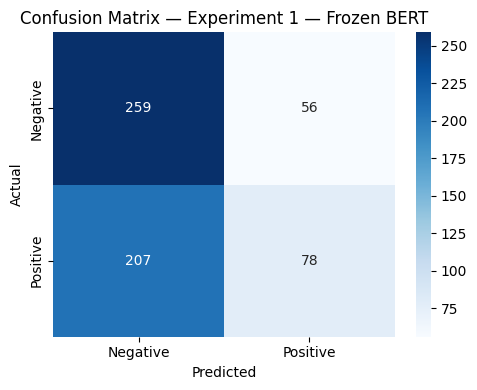

In [11]:
true_exp1, pred_exp1 = evaluate(model_exp1, test_loader)
metrics_exp1 = print_metrics(true_exp1, pred_exp1, 'Experiment 1 — Frozen BERT')
plot_cm(true_exp1, pred_exp1, 'Experiment 1 — Frozen BERT')

---
## Experiment 2 — Fine-Tune Last 2 BERT Layers + Classifier
All BERT layers are frozen except encoder layers 10 and 11 (the last 2 out of 12). These top layers hold the most task-specific representations, so fine-tuning them adapts BERT to sentiment classification.

In [12]:
model_exp2 = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

# Freeze all BERT layers first
for param in model_exp2.bert.parameters():
    param.requires_grad = False

# Unfreeze last 2 encoder layers (10 and 11)
for layer_idx in [10, 11]:
    for param in model_exp2.bert.encoder.layer[layer_idx].parameters():
        param.requires_grad = True

model_exp2 = model_exp2.to(device)
optimizer_exp2 = AdamW(model_exp2.parameters(), lr=2e-5, weight_decay=0.01)

trainable = sum(p.numel() for p in model_exp2.parameters() if p.requires_grad)
print(f'Trainable parameters: {trainable:,}')

Loading weights: 100%|█████████████████████████████████████████████████████████████| 199/199 [00:00<00:00, 4514.96it/s]
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initializ

Trainable parameters: 14,177,282


In [ ]:
exp2_losses = []

for epoch in range(EPOCHS):
    loss = train_epoch(model_exp2, train_loader, optimizer_exp2)
    exp2_losses.append(loss)
    val_labels, val_preds = evaluate(model_exp2, val_loader)
    print(f'Epoch {epoch+1}/{EPOCHS} | Loss: {loss:.4f} | Val Acc: {accuracy_score(val_labels, val_preds):.4f}')

In [ ]:
true_exp2, pred_exp2 = evaluate(model_exp2, test_loader)
metrics_exp2 = print_metrics(true_exp2, pred_exp2, 'Experiment 2 — Last 2 Layers Fine-Tuned')
plot_cm(true_exp2, pred_exp2, 'Experiment 2 — Last 2 Layers Fine-Tuned')

---
## Experiment Comparison

In [ ]:
comparison = pd.DataFrame({
    'Metric'                  : ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Exp 1 (Frozen BERT)'     : [round(metrics_exp1[k], 4) for k in ['accuracy','precision','recall','f1']],
    'Exp 2 (Last 2 Layers)'   : [round(metrics_exp2[k], 4) for k in ['accuracy','precision','recall','f1']]
})

print(comparison.to_string(index=False))

In [ ]:
# Bar chart comparing metrics across both experiments
metrics_list = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
exp1_vals = [metrics_exp1[k] for k in ['accuracy','precision','recall','f1']]
exp2_vals = [metrics_exp2[k] for k in ['accuracy','precision','recall','f1']]

x = np.arange(len(metrics_list))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x - width/2, exp1_vals, width, label='Exp 1: Frozen BERT', color='steelblue', alpha=0.85)
b2 = ax.bar(x + width/2, exp2_vals, width, label='Exp 2: Last 2 Layers', color='darkorange', alpha=0.85)

for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(metrics_list)
ax.set_ylim(0, 1.1)
ax.set_title('Experiment Comparison — IMDB Sentiment Classification')
ax.legend()
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
# Training loss per epoch
plt.figure(figsize=(7, 4))
plt.plot(range(1, EPOCHS+1), exp1_losses, marker='o', label='Exp 1: Frozen BERT', color='steelblue')
plt.plot(range(1, EPOCHS+1), exp2_losses, marker='s', label='Exp 2: Last 2 Layers', color='darkorange')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Training Loss — Experiment Comparison')
plt.xticks(range(1, EPOCHS+1))
plt.legend()
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()